# 06 — Explainability, Segmentation and Decisions

Two audiences:

* **Global** — which features drive the model, to check it learned the relationships the EDA found rather than an artefact.
* **Local** — why *this* customer scored what they did, in language a retention agent can act on.

Requires a trained bundle: run `make train` first.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
warnings.filterwarnings('ignore')

from src.config import load_config
cfg = load_config()

In [2]:
from src.data.loader import make_dataset
from src.models.persist import load_model
from src.data.schema import feature_columns

ds = make_dataset(cfg)
bundle = load_model(cfg)
fitted = bundle['explainer_pipeline']
scorer = bundle['model']
print('model:', bundle['metadata']['model_name'])
print('threshold:', bundle['metadata']['threshold'])

model: xgboost
threshold: 0.13


## Global importance

Aggregated back to business features: one-hot encoding splits one concept across several columns and understates it. `Contract` split three ways looks less important than it is until the parts are summed.

In [3]:
from src.explainability.shap_analysis import compute_shap
art = compute_shap(fitted, ds.X_test, max_samples=1000, seed=cfg.seed)
art.grouped_importance(feature_columns()).head(12).round(4)

,base_feature,mean_abs_shap
0,is_month_to_month,0.4794
1,tenure,0.4171
2,Contract,0.4126
3,OnlineSecurity,0.2356
4,InternetService,0.2017
5,TechSupport,0.1954
6,PaymentMethod,0.1848
7,MonthlyCharges,0.1474
8,realized_arpu,0.1468
9,PaperlessBilling,0.1185


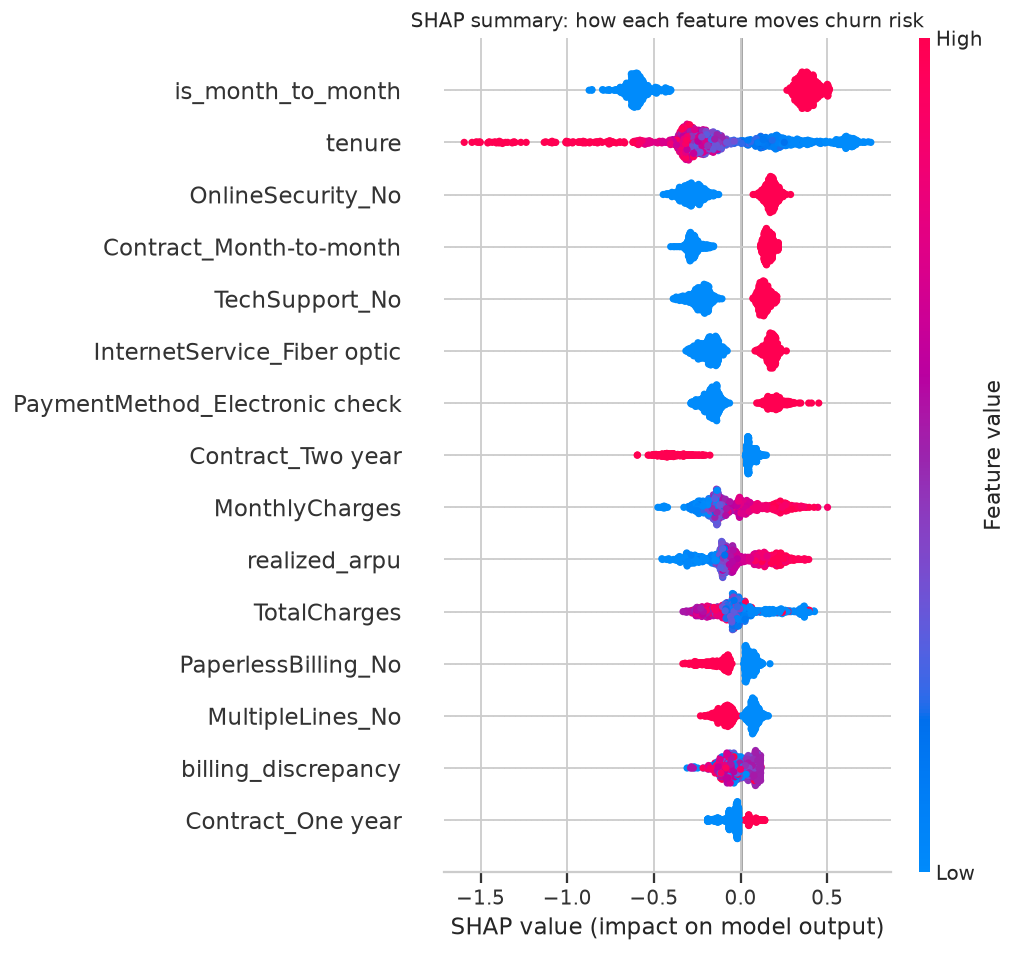

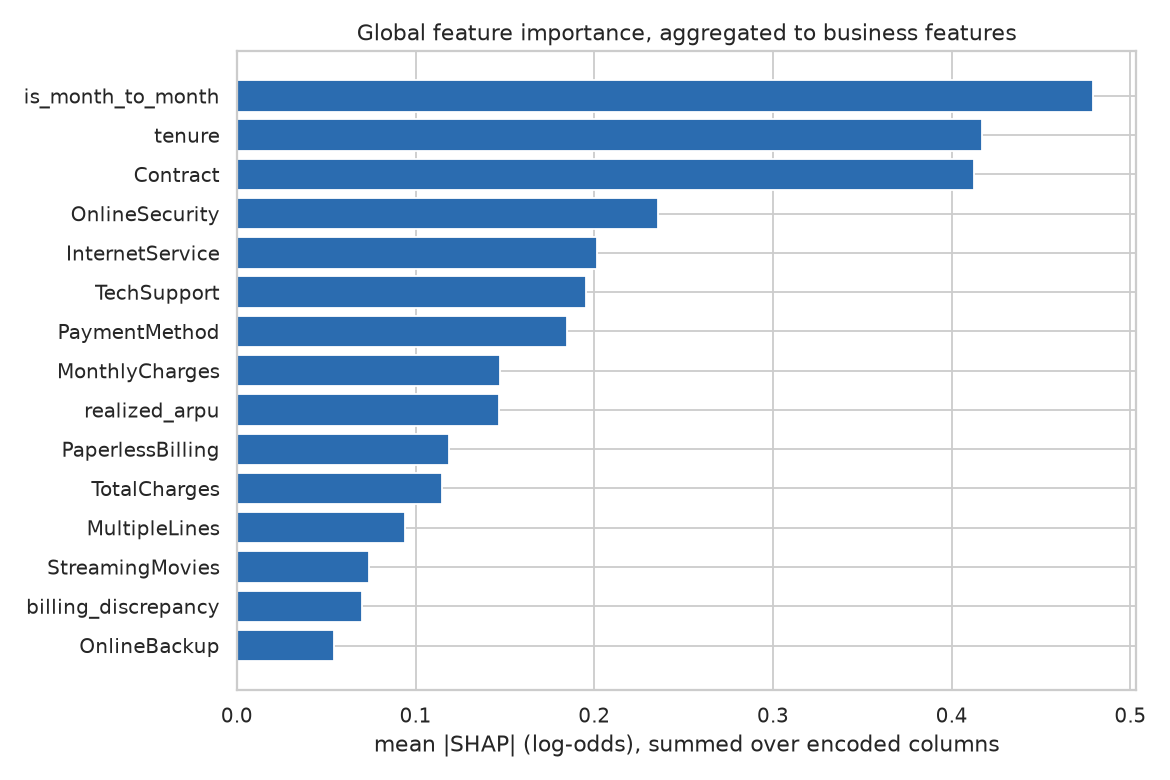

In [4]:
from IPython.display import Image, display
figdir = cfg.resolve('paths', 'figures_dir')
for f in ('07_shap_summary.png', '08_shap_importance_grouped.png'):
    p = figdir / f
    if p.exists():
        display(Image(str(p)))

## Per-customer explanations

Contributions are in **log-odds** and are not additive in probability, so the plain-language layer reports direction and relative magnitude rather than 'this added 8% to your risk'.

Phrasing is derived from the customer's **actual value**, never from the name of an encoded column — doing it the other way inverts the meaning of every one-hot term.

In [5]:
from src.explainability.shap_analysis import (explain_customer,
                                              representative_customers)
prob_all = scorer.predict_proba(ds.X_test)[:, 1]
sub = prob_all[art.raw.index.to_numpy()]
picks = representative_customers(sub, art, cfg=cfg)

for band, pos in picks.items():
    row = art.raw.iloc[pos]
    exp = explain_customer(art, pos, feature_columns())
    print(f'\n[{band}] churn {sub[pos]:.1%} | {row["Contract"]}, '
          f'tenure {row["tenure"]}m, {row["MonthlyCharges"]:.2f}/month')
    for f in exp['top_risk_factors']:
        print(f'   + {f["reason"]}  ({f["contribution"]:+.3f})')
    for f in exp['top_protective_factors']:
        print(f'   - {f["reason"]}  ({f["contribution"]:+.3f})')


[Low Risk] churn 2.2% | One year, tenure 53m, 20.20/month
   + pays in line with their billing history  (+0.115)
   - has no internet service  (-0.814)
   - is on a one year contract  (-0.677)
   - pays 20.20 per month  (-0.596)
   - has been a customer for 53 months  (-0.361)

[Medium Risk] churn 20.2% | Month-to-month, tenure 3m, 19.95/month
   + is on a month-to-month contract  (+0.626)
   + has been a customer for 3 months  (+0.452)
   + now pays 1.03x their historical average (a recent increase)  (+0.133)
   - has no internet service  (-0.983)
   - pays 19.95 per month  (-0.177)
   - receives paper bills  (-0.165)
   - pays by mailed check  (-0.135)

[High Risk] churn 48.3% | Month-to-month, tenure 3m, 25.25/month
   + is on a month-to-month contract  (+0.625)
   + has been a customer for 3 months  (+0.367)
   + pays by electronic check  (+0.218)
   + has no online-security add-on  (+0.217)
   - receives paper bills  (-0.377)
   - has DSL internet  (-0.216)
   - pays 25.25 per mo

## Risk segmentation, validated

The bands are checked against **realised** churn on the test set. A band whose realised rate does not match its label is a broken band, however tidy the cut points look.

In [6]:
from src.evaluation.segments import segment_summary, validate_segments
from src.evaluation.threshold import Economics
econ = Economics.from_config(cfg)
value = econ.customer_value(ds.X_test)
seg = segment_summary(prob_all, ds.y_test.to_numpy(), cfg, value=value)
seg.drop(columns=['recommended_action']).round(4)

,customers,avg_predicted_risk,realised_churn_rate,churners,avg_customer_value,value_at_risk,share_of_customers,share_of_churners
risk_segment,,,,,,,,
Low Risk,528,0.0338,0.0455,24,630.6341,332974.8,0.3755,0.0645
Medium Risk,428,0.2062,0.2173,93,806.0790,345001.8,0.3044,0.2500
High Risk,308,0.4927,0.5032,155,879.4130,270859.2,0.2191,0.4167
Critical Risk,142,0.7612,0.7042,100,977.7718,138843.6,0.1010,0.2688


In [7]:
validate_segments(seg)

{'monotonic_realised_churn': True,
 'max_abs_calibration_gap': 0.05693639248189797,
 'lowest_band_churn': 0.045454545454545456,
 'highest_band_churn': 0.704225352112676,
 'lift_top_vs_bottom': 15.492957746478872}

In [8]:
for band, action in seg['recommended_action'].items():
    print(f'{band:15s} {action}')

Low Risk        Normal engagement. No retention spend; include in standard lifecycle comms and monitor for band changes.
Medium Risk     Low-cost nurture. Service review, add-on education, or a bundle recommendation. Automated channels only.
High Risk       Proactive outreach. Targeted offer or contract-term incentive, prioritised by customer value.
Critical Risk   Priority intervention. Human contact with retention authority, subject to the customer clearing the expected-value test.


## The decision layer

Risk alone is not a decision. Every action is gated on an expected-value test, so a low-value customer at high risk whose expected saving does not cover the offer is deliberately not contacted.

In [9]:
from src.inference.decision import decide, campaign_summary
decisions = decide(prob_all, ds.X_test, cfg)
campaign_summary(decisions).round(2)

,risk_segment,value_tier,customers,avg_risk,avg_value_cu,contacts,expected_value_cu,priority
0,Critical Risk,High value,55,0.76,1152.10,55,12555.37,1
1,High Risk,High value,116,0.50,1163.65,116,16007.01,2
2,Critical Risk,Standard value,87,0.76,867.57,87,14178.49,3
3,High Risk,Standard value,192,0.49,707.69,178,13656.14,4
4,Medium Risk,High value,151,0.22,1212.10,149,6582.09,5
5,Medium Risk,Standard value,277,0.20,584.75,122,2364.47,6
6,Low Risk,High value,102,0.05,1215.86,6,14.64,7
7,Low Risk,Standard value,426,0.03,490.51,0,0.00,8


In [10]:
print(f"contacts recommended : {int(decisions['contact_recommended'].sum())}"
      f" of {len(decisions)}")
print(f"EV overrides band    : {int(decisions['ev_overrides_segment'].sum())}")

contacts recommended : 713 of 1406
EV overrides band    : 277


## End-to-end inference

The shape an API would return for one customer.

In [11]:
from src.inference.predict import ChurnPredictor, EXAMPLE_CUSTOMER, format_result
predictor = ChurnPredictor.load(cfg)
print(format_result(predictor.predict_one(EXAMPLE_CUSTOMER)))

CHURN PREDICTION
  churn probability   : 79.1%
  risk segment        : Critical Risk
  value tier          : High value (1,133 CU over the horizon)
  break-even risk     : 10.3% (contact pays off above this)
  expected value      : +234 CU
  contact recommended : YES
  priority            : 1  via outbound call

  ACTION: Priority retention call from a senior agent with discretionary discount authority and a contract-term offer.

  Why this customer is at risk:
    + is on a month-to-month contract
    + has been a customer for 2 months
    + pays 94.40 per month
    + has no online-security add-on
  What is holding them:
    - has a single phone line

  note: Currency figures use the assumed retention economics in configs/config.yaml; they are not measured business results.
